https://youtu.be/hPZiCM5I0o4

## 1. Predição de preços de diamantes (2 pts)

#### EDA e Pré Processamento

##### 1.1 carregando e visualizando dados

In [40]:
import pandas as pd
path = 'diamonds.csv'
diamonds = pd.read_csv('diamonds.csv', index_col=0)
print(diamonds.describe())
diamonds.head()

              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700000     61.800000     57.000000   2401.000000      5.700000   
75%        1.040000     62.500000     59.000000   5324.250000      6.540000   
max        5.010000     79.000000     95.000000  18823.000000     10.740000   

                  y             z  
count  53940.000000  53940.000000  
mean       5.734526      3.538734  
std        1.142135      0.705699  
min        0.000000      0.000000  
25%        4.720000      2.910000  
50%        5.710000      3.530000  
75%        6.540000      4.040000  


,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


##### 1.2 EDA das possíveis features

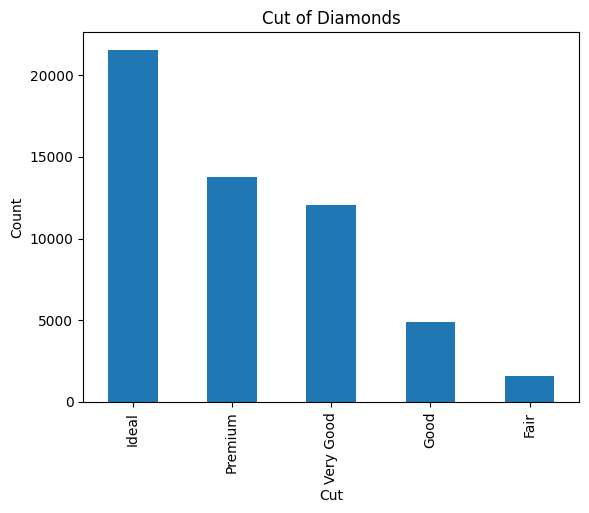

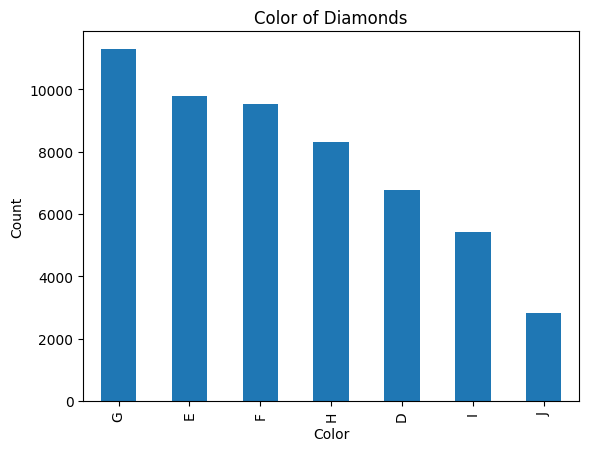

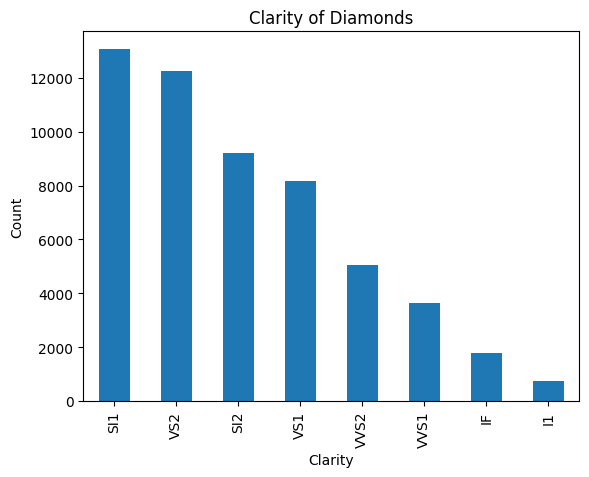

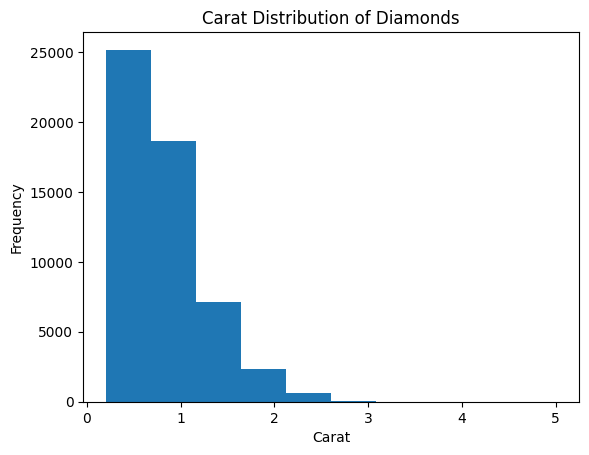

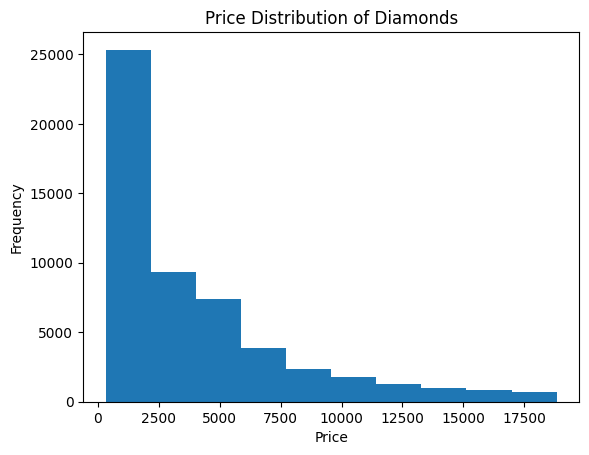

In [41]:
diamonds['cut'].value_counts().plot(kind='bar', title='Cut of Diamonds')
import matplotlib.pyplot as plt
plt.xlabel('Cut')
plt.ylabel('Count')
plt.show()
diamonds['color'].value_counts().plot(kind='bar', title='Color of Diamonds')
plt.xlabel('Color')
plt.ylabel('Count')
plt.show()
diamonds['clarity'].value_counts().plot(kind='bar', title='Clarity of Diamonds')
plt.xlabel('Clarity')
plt.ylabel('Count')
plt.show()
diamonds['carat'].plot(kind='hist', title='Carat Distribution of Diamonds')
plt.xlabel('Carat')
plt.ylabel('Frequency')
plt.show()
diamonds['price'].plot(kind='hist', title='Price Distribution of Diamonds')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

#####  1.3 Comparação entre a distribuição original e a distribuição log-transformada dos preços dos diamantes

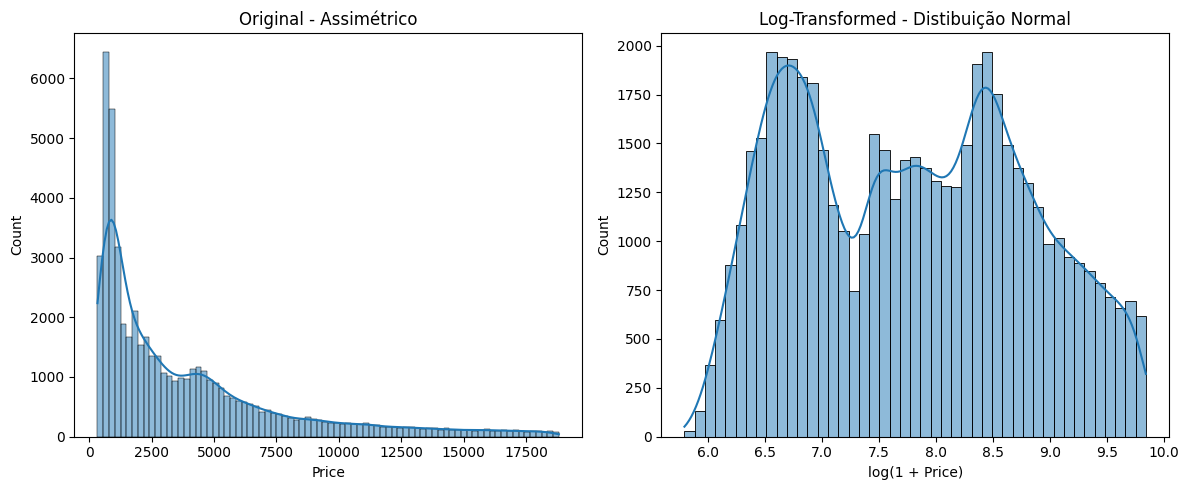

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 5))  # Adjust the figure size as needed

# Original distribution
plt.subplot(1, 2, 1)
sns.histplot(diamonds['price'], kde=True)
plt.title("Original - Assimétrico")
plt.xlabel("Price")

# Log-transformed para normalizar a feature
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(diamonds['price']), kde=True) #log1p evita erros com log(0)
plt.title("Log-Transformed - Distibuição Normal")
plt.xlabel("log(1 + Price)")

plt.tight_layout()
plt.show()

##### 1.4 Pré Processamento


In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

class DiamondsDataset:
    def __init__(self, dataframe: pd.DataFrame, target_column: str):
        self.df = dataframe.copy()
        self.target_column = target_column
        self.encoder = None
        self.scaler = None

        self.categorical_cols = ['cut', 'color', 'clarity']
        self.category_orders = [
            ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],  # cut
            ['J', 'I', 'H', 'G', 'F', 'E', 'D'],                # color
            ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']  # clarity
        ]

    def split_train_test_val(self, test_size=0.2, val_size=0.0, random_state=42): # posso sobrescrever esses parâmetros
        X = self.df.drop(columns=[self.target_column]) # features
        y = self.df[self.target_column] # preço do diamante

        # Primeiro, divide em treino e teste mas essa função não retorna nada ainda
        X_temp, self.X_test, y_temp, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state)

        if val_size > 0: # train_test_split não aceita proporção de validação, então criamos 
            val_relative = val_size / (1 - test_size)
            self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
                X_temp, y_temp, test_size=val_relative, random_state=random_state)
        else:
            self.X_train, self.X_val, self.y_train, self.y_val = X_temp, None, y_temp, None

    def encode_categorical(self):
        self.encoder = OrdinalEncoder(categories=self.category_orders)

        self.X_train[self.categorical_cols] = self.encoder.fit_transform(self.X_train[self.categorical_cols]) # .fit_transform é diferente de .transform

        if self.X_val is not None:
            self.X_val[self.categorical_cols] = self.encoder.transform(self.X_val[self.categorical_cols]) 

        self.X_test[self.categorical_cols] = self.encoder.transform(self.X_test[self.categorical_cols])# .transform aplica a transformação já aprendida no fit

    def scale_numeric(self): # Padroniza variáveis numéricas (z-score) usando média e desvio do treino (features com escalas diferentes)
        numeric_cols = self.X_train.select_dtypes(include='number').columns.difference([self.target_column])
        self.scaler = StandardScaler()

        self.X_train[numeric_cols] = self.scaler.fit_transform(self.X_train[numeric_cols])

        if self.X_val is not None:
            self.X_val[numeric_cols] = self.scaler.transform(self.X_val[numeric_cols])

        self.X_test[numeric_cols] = self.scaler.transform(self.X_test[numeric_cols])

    def get_train_val_test(self):
        return self.X_train, self.X_val, self.X_test, self.y_train, self.y_val, self.y_test

    def get_encoder(self):
        return self.encoder

    def get_scaler(self):
        return self.scaler


##### 1.5 Pré Processamento no conjunto diamonds


In [44]:
dataset = DiamondsDataset(diamonds, target_column='price')
dataset.split_train_test_val(test_size=0.2, val_size=0.2) # Divida os dados em três conjuntos: treino (60%), validação (20%) e teste (20%)
dataset.encode_categorical() # Codifique os atributos categóricos
dataset.scale_numeric() # Padronize os atributos numéricos

X_train, X_val, X_test, y_train, y_val, y_test = dataset.get_train_val_test()

In [45]:
X_train.head()  # Exibe as primeiras linhas do novo conjunto de treino


,carat,cut,color,clarity,depth,table,x,y,z
40286,-1.055022,0.975504,-0.239254,-0.029187,0.318479,-1.547880,-1.291100,-1.216402,-1.207897
4259,0.210936,-0.817754,-1.417823,0.578277,1.086287,0.690419,0.323916,0.274987,0.431859
15763,0.865015,0.975504,-0.828538,-0.029187,0.807084,-0.204901,0.948507,0.869819,1.006474
48293,-0.548639,0.975504,-0.239254,0.578277,-0.798332,-0.652561,-0.407749,-0.371569,-0.465102
12586,1.076008,0.078875,-1.417823,-0.636651,0.178878,0.242759,1.135885,1.068096,1.118594


#### Escolha e treinamento do modelo com conjunto de validação

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score # Métricas de avaliação

# Dicionário de modelos
models = {
    "Linear Regression": LinearRegression(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

# Avaliar os modelos no conjunto de validação
validation_rmse = {} # Guarda os RMSE (erros) de validação para cada modelo
for name, model in models.items(): # iterar sobre os modelos
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred_val, squared=False)
    validation_rmse[name] = rmse
    print(f"RMSE (validação) - {name}: {rmse:.2f}")

# Escolher o modelo com menor RMSE na validação
best_model_name = min(validation_rmse, key=validation_rmse.get)
best_model = models[best_model_name]
print(f"\n✅ Melhor modelo: {best_model_name}")




RMSE (validação) - Linear Regression: 1186.29
RMSE (validação) - K-Nearest Neighbors: 730.54
RMSE (validação) - Gradient Boosting: 618.38

✅ Melhor modelo: Gradient Boosting


#### Resultados no conjunto de teste

In [47]:
# Avaliar no conjunto de teste
y_pred_test = best_model.predict(X_test)
rmse_test = mean_squared_error(y_test, y_pred_test, squared=False)
mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
r2_test = r2_score(y_test, y_pred_test)

print(f"\n📊 Avaliação no conjunto de teste:")
print(f"RMSE (teste): {rmse_test:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R² (teste): {r2_test:.4f}")


📊 Avaliação no conjunto de teste:
RMSE (teste): 605.09
MAPE: 10.99%
R² (teste): 0.9770


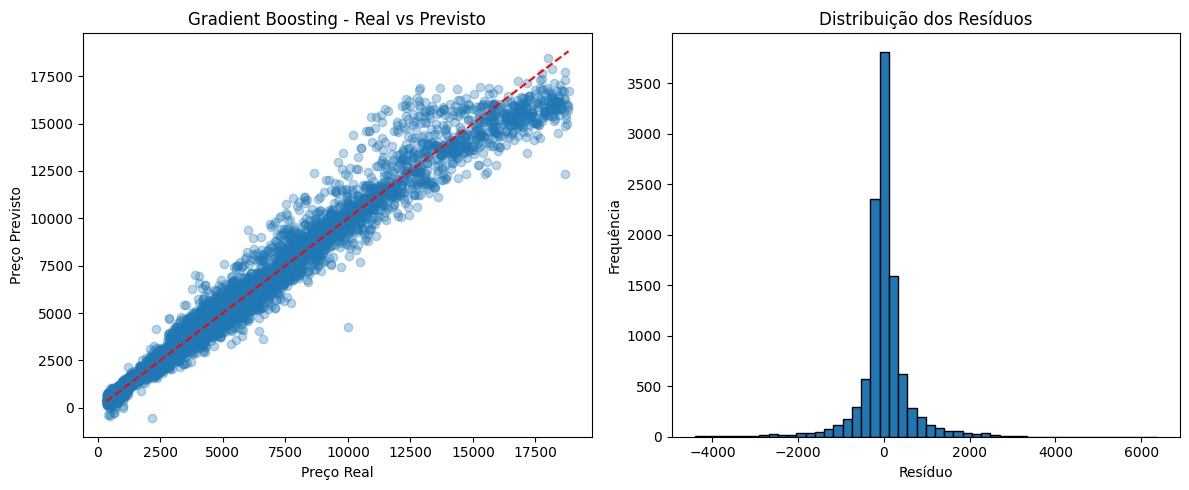

In [48]:
# Gráficos para análise
plt.figure(figsize=(12, 5))

# Gráfico de dispersão real vs previsto
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Preço Real")
plt.ylabel("Preço Previsto")
plt.title(f"{best_model_name} - Real vs Previsto")

# Gráfico de distribuição dos resíduos
residuos = y_test - y_pred_test
plt.subplot(1, 2, 2)
plt.hist(residuos, bins=50, edgecolor='black')
plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

## 2. Redes Neurais MLP com PyTorch (2 pts)

### 2.1 Parte A – Classificação

#### 2.1.1 EDA

Primeiras amostras do dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines

C:\Users\João Pedro\AppData\Local\Temp\ipykernel_13676\1145872398.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


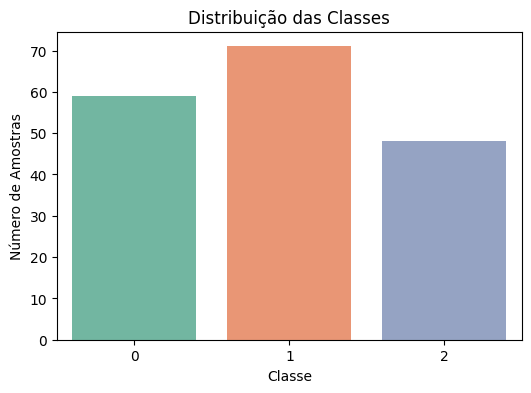

C:\Users\João Pedro\AppData\Local\Temp\ipykernel_13676\1145872398.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='alcohol', data=df, palette='Set2')


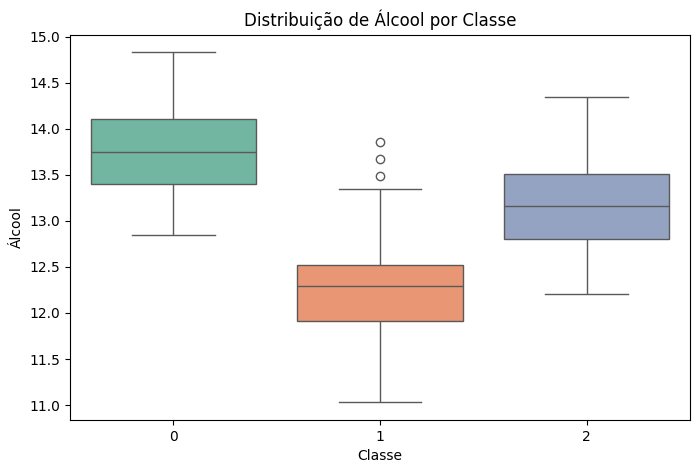

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Carregar o dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# 1. Exibir as primeiras amostras
print("Primeiras amostras do dataset:")
print(df.head())

# 2. Ver distribuição das classes
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Número de Amostras")
plt.show()

# 3. Boxplot da feature 'alcohol' por classe
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='alcohol', data=df, palette='Set2')
plt.title("Distribuição de Álcool por Classe")
plt.xlabel("Classe")
plt.ylabel("Álcool")
plt.show()
print(df.describe())


#### 2.1.2 Pré Processamento



In [50]:
# 1. Importação 
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 2. Carregamento e divisão 
X, y = load_wine(return_X_y=True)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)


# 3. Normalização para igualar as escalas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # .fit_transform ajusta o scaler com dados de treino e transforma todos os outros dados
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Exibição das dimensões e primeiras linhas
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("Primeiras linhas de X_train:\n", X_train[:5])
print("Primeiros valores de y_train:", y_train[:10])

X_train shape: (106, 13)
X_val shape: (36, 13)
X_test shape: (36, 13)
Primeiras linhas de X_train:
 [[ 0.95817987 -0.68509096  1.2406911   0.00903313  2.06926091  1.08120553
   0.78503623  1.20204481 -0.44822156  0.12419372  1.24696915  0.63687539
   1.52698895]
 [-0.35275089 -1.21898754 -0.41265949 -0.48623138 -0.1109423  -0.12790742
  -0.05317924 -0.49797854 -0.25906979 -1.01378527  1.16178598  0.87484425
  -0.97042148]
 [ 0.74169589 -0.55889723  0.01864936 -0.12303741  0.35152505  0.93611197
   1.25653243 -1.17798787  0.58351536  0.73821116  0.56550377  0.45839874
   2.41778503]
 [ 1.07844875 -0.70450539  1.13286389  1.82500297 -0.96981023  1.08120553
   0.91076855 -1.26298904  0.44595044 -0.7026831   1.71547661  0.87484425
  -1.09767806]
 [ 0.10427085 -0.18031601  3.10969612  1.82500297  1.5407268   0.56531734
   0.72217007  0.94704131  0.53192851 -0.62081411  0.73587011  0.93433647
   0.23851605]]
Primeiros valores de y_train: [0 1 0 1 0 0 2 0 1 0]


#### 2.1.3 Conversão para tensor 

In [51]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)


#### 2.1.4 Definição de modelo MLP pra classificação

In [52]:
import torch.nn as nn

class MLP(nn.Module): # Definição de uma rede neural simples (MLP) com uma camada oculta
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(X.shape[1], 32) # X.shape[1] é o número de features e 32 é o número de neurônios na camada oculta 
        self.relu = nn.ReLU() # Função de ativação ReLU para introduzir não-linearidade
        self.output = nn.Linear(32, 3)  # 3 classes no wine

    def forward(self, x): # Método de propagação direta
        x = self.relu(self.hidden(x)) # Aplica a camada oculta seguida da função de ativação ReLU
        return self.output(x) # Retorna a saída bruta da camada final, que produz logits para as 3 classes

model = MLP()


#### 2.1.5 Treinamento

In [53]:
# Adam usa Momentum (velocidade de mudança dos pesos) e RMSprop (ajuste do passo com base no histórico do gradiente).
import torch.optim as optim # Otimizador Adam para atualizar os pesos da rede neural
import torch.nn as nn # Biblioteca para construir redes neurais em PyTorch


loss_fn = nn.CrossEntropyLoss() # Função de perda de entropia cruzada para classificação multiclasse
optimizer = optim.Adam(model.parameters(), lr=0.01) # Otimizador Adam para atualizar os pesos da rede neural lr = taxa de aprendizado
losses = [] # Lista para armazenar as perdas durante o treinamento

probs = [] # Lista para armazenar as probabilidades previstas durante o treinamento
correct = [] # Lista para armazenar as previsões corretas durante o treinamento

for epoch in range(50): # Treinamento por 50 
    model.train() # Muda o modelo para o modo de treinamento
    outputs = model(X_train_t) # Propagação direta: calcula as previsões da rede neural para os dados de treino
    loss = loss_fn(outputs, y_train_t) # Calcula a perda entre as previsões e os rótulos reais
    losses.append(loss.item()) # Armazena a perda para análise posterior

    # Backpropagation: calcula os gradientes da perda em relação aos pesos da rede neural
    optimizer.zero_grad() # Zera os gradientes acumulados do otimizador
    loss.backward() # Calcula os gradientes da perda em relação aos pesos da rede neural
    optimizer.step() # Atualiza os pesos da rede neural com base nos gradientes calculados

    with torch.no_grad(): # Desativa o cálculo de gradientes para economizar memória e acelerar a computação
        pred_probs = torch.softmax(outputs, dim=1).cpu().numpy() # Calcula as probabilidades previstas usando a função softmax
        epoch_probs = pred_probs[np.arange(len(y_train)), y_train] # Extrai as probabilidades correspondentes às classes reais
        probs.append(epoch_probs) # Armazena as probabilidades previstas para análise posterior

        preds = np.argmax(pred_probs, axis=1) # Obtém as classes previstas pela rede neural, escolhendo a classe com a maior probabilidade
        epoch_correct = (preds == y_train).astype(int) # Compara as classes previstas com as classes reais e converte o resultado em 0s e 1s (0 para incorreto, 1 para correto)
        correct.append(epoch_correct) # Armazena as previsões corretas para análise posterior


#### 2.1.6 Avaliação

In [54]:
model.eval() # Muda o modelo para o modo de avaliação, desativando dropout e batch normalization 
with torch.no_grad(): # Desativa o cálculo de gradientes para economizar memória e acelerar a inferência
    pred = model(X_test_t).argmax(dim=1) # Obtém as previsões da rede neural para os dados de teste e seleciona a classe com maior probabilidade
    accuracy = (pred == y_test_t).float().mean().item() # Calcula a acurácia como a proporção de previsões corretas
    print(f"Acurácia no teste: {accuracy * 100:.2f}%") # Exibe a acurácia no conjunto de teste


Acurácia no teste: 100.00%


#### 2.1.7 Curva de perda

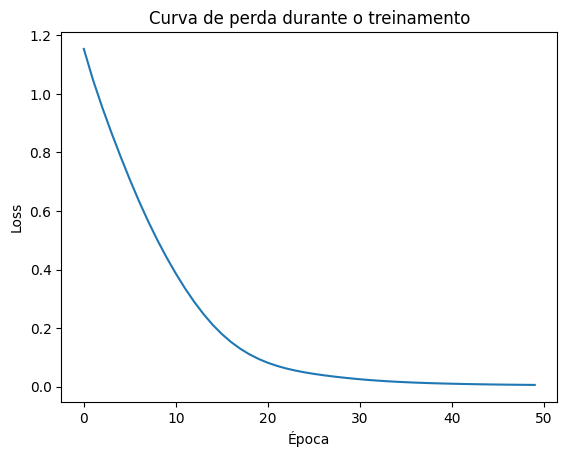

In [55]:
plt.plot(losses)
plt.title("Curva de perda durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()


### 2.2 Parte B – Regressão

#### 2.2.1 EDA

Amostras iniciais:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      

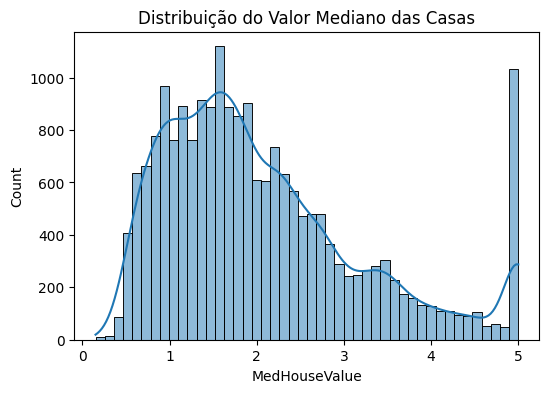

In [56]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target
print("Amostras iniciais:")
print(X.head())
print(X.describe())

# Distribuição do target
plt.figure(figsize=(6, 4))
sns.histplot(y, kde=True)
plt.title("Distribuição do Valor Mediano das Casas")
plt.xlabel("MedHouseValue")
plt.show()


#### 2.2.2 Pré Processamento

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Divisão inicial em treino+validação e teste
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42) # Divisão do treino+validação em treino e validação

scaler = StandardScaler() # Padronização para igualar as escalas
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
# Exibição das dimensões e primeiras linhas
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("Primeiras linhas de X_train:\n", X_train[:5])
print("Primeiros valores de y_train:", y_train[:10])

X_train shape: (12384, 8)
X_val shape: (4128, 8)
X_test shape: (4128, 8)
Primeiras linhas de X_train:
 [[-0.79547754  0.8260251  -0.71694298 -0.20409736 -0.02041282  0.10188491
  -0.56877746 -0.04497204]
 [ 3.31836617 -0.36373696  1.03623684 -0.29694588  0.7193329  -0.03451767
  -0.89258573  0.628346  ]
 [-1.16419606  0.98466004 -0.72389784 -0.4853724  -0.50072165 -0.06971956
   1.63687302 -1.01754255]
 [ 0.51013134 -1.55349902 -0.10144629 -0.22863372  0.40029565 -0.13771992
  -0.65794206  0.47373223]
 [ 0.91099754  0.74670763  0.76936986 -0.3117686  -0.37976796 -0.07305618
   0.8813204  -1.35669534]]
Primeiros valores de y_train: [2.414   5.00001 0.641   2.772   4.17    5.00001 3.677   5.00001 3.762
 0.535  ]


#### 2.2.3 Conversão para tensor 

In [58]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

#### 2.2.4 Definição de modelo MLP pra regressão

In [59]:
class MLPRegressor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLPRegressor(X.shape[1])
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

#### 2.2.5 Treinamento

In [60]:
# Definição de uma rede neural simples (MLP) com uma camada oculta
epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    pred = model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t)
        val_losses.append(val_loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

#### 2.2.6 Avaliação

In [61]:
from sklearn.metrics import mean_squared_error

model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_t)
    rmse = mean_squared_error(y_test, y_pred_test.numpy(), squared=False)
    print(f"RMSE no conjunto de teste: {rmse:.4f}")

RMSE no conjunto de teste: 0.6033


#### 2.2.7 Curva de perda

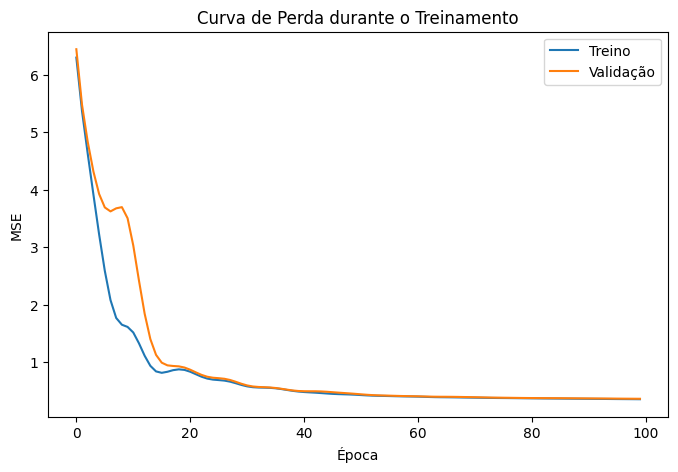

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.title("Curva de Perda durante o Treinamento")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.show()

## 3. Diagnóstico de qualidade (2 pts)

#### 2.1.2 Pré Processamento, definição e treino 



In [63]:
# 1. Importação 
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 2. Carregamento e divisão 
X, y = load_wine(return_X_y=True)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)


# 3. Normalização para igualar as escalas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # .fit_transform ajusta o scaler com dados de treino e transforma todos os outros dados
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Exibição das dimensões e primeiras linhas
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("Primeiras linhas de X_train:\n", X_train[:5])
print("Primeiros valores de y_train:", y_train[:10])

X_train shape: (106, 13)
X_val shape: (36, 13)
X_test shape: (36, 13)
Primeiras linhas de X_train:
 [[ 0.95817987 -0.68509096  1.2406911   0.00903313  2.06926091  1.08120553
   0.78503623  1.20204481 -0.44822156  0.12419372  1.24696915  0.63687539
   1.52698895]
 [-0.35275089 -1.21898754 -0.41265949 -0.48623138 -0.1109423  -0.12790742
  -0.05317924 -0.49797854 -0.25906979 -1.01378527  1.16178598  0.87484425
  -0.97042148]
 [ 0.74169589 -0.55889723  0.01864936 -0.12303741  0.35152505  0.93611197
   1.25653243 -1.17798787  0.58351536  0.73821116  0.56550377  0.45839874
   2.41778503]
 [ 1.07844875 -0.70450539  1.13286389  1.82500297 -0.96981023  1.08120553
   0.91076855 -1.26298904  0.44595044 -0.7026831   1.71547661  0.87484425
  -1.09767806]
 [ 0.10427085 -0.18031601  3.10969612  1.82500297  1.5407268   0.56531734
   0.72217007  0.94704131  0.53192851 -0.62081411  0.73587011  0.93433647
   0.23851605]]
Primeiros valores de y_train: [0 1 0 1 0 0 2 0 1 0]


In [64]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [65]:
import torch.nn as nn

class MLP(nn.Module): # Definição de uma rede neural simples (MLP) com uma camada oculta
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(X.shape[1], 32) # X.shape[1] é o número de features e 32 é o número de neurônios na camada oculta 
        self.relu = nn.ReLU() # Função de ativação ReLU para introduzir não-linearidade
        self.output = nn.Linear(32, 3)  # 3 classes no wine

    def forward(self, x): # Método de propagação direta
        x = self.relu(self.hidden(x)) # Aplica a camada oculta seguida da função de ativação ReLU
        return self.output(x) # Retorna a saída bruta da camada final, que produz logits para as 3 classes

model = MLP()


In [66]:
# Adam usa Momentum (velocidade de mudança dos pesos) e RMSprop (ajuste do passo com base no histórico do gradiente).
import torch.optim as optim # Otimizador Adam para atualizar os pesos da rede neural
import torch.nn as nn # Biblioteca para construir redes neurais em PyTorch


loss_fn = nn.CrossEntropyLoss() # Função de perda de entropia cruzada para classificação multiclasse
optimizer = optim.Adam(model.parameters(), lr=0.01) # Otimizador Adam para atualizar os pesos da rede neural lr = taxa de aprendizado
losses = [] # Lista para armazenar as perdas durante o treinamento

probs = [] # Lista para armazenar as probabilidades previstas durante o treinamento
correct = [] # Lista para armazenar as previsões corretas durante o treinamento

for epoch in range(50): # Treinamento por 50 
    model.train() # Muda o modelo para o modo de treinamento
    outputs = model(X_train_t) # Propagação direta: calcula as previsões da rede neural para os dados de treino
    loss = loss_fn(outputs, y_train_t) # Calcula a perda entre as previsões e os rótulos reais
    losses.append(loss.item()) # Armazena a perda para análise posterior

    # Backpropagation: calcula os gradientes da perda em relação aos pesos da rede neural
    optimizer.zero_grad() # Zera os gradientes acumulados do otimizador
    loss.backward() # Calcula os gradientes da perda em relação aos pesos da rede neural
    optimizer.step() # Atualiza os pesos da rede neural com base nos gradientes calculados

    with torch.no_grad(): # Desativa o cálculo de gradientes para economizar memória e acelerar a computação
        pred_probs = torch.softmax(outputs, dim=1).cpu().numpy() # Calcula as probabilidades previstas usando a função softmax
        epoch_probs = pred_probs[np.arange(len(y_train)), y_train] # Extrai as probabilidades correspondentes às classes reais
        probs.append(epoch_probs) # Armazena as probabilidades previstas para análise posterior

        preds = np.argmax(pred_probs, axis=1) # Obtém as classes previstas pela rede neural, escolhendo a classe com a maior probabilidade
        epoch_correct = (preds == y_train).astype(int) # Compara as classes previstas com as classes reais e converte o resultado em 0s e 1s (0 para incorreto, 1 para correto)
        correct.append(epoch_correct) # Armazena as previsões corretas para análise posterior


#### 3.1 Calcular confiança, variabilidade e corretude

In [67]:
probs = np.stack(probs, axis=1) # Empilha as probabilidades previstas ao longo das épocas
correct = np.stack(correct, axis=1) # Empilha as previsões corretas ao longo das épocas
confidence = probs.mean(axis=1) # Calcula a confiança média das previsões ao longo das épocas
variability = probs.std(axis=1) # Calcula a variabilidade das previsões ao longo das épocas
accuracy_ratio = correct.mean(axis=1) # Calcula a proporção de previsões corretas ao longo das épocas

#### 3.2 Criando DataFrame

In [68]:
df_map = pd.DataFrame({
    'confiança': confidence,
    'variabilidade': variability,
    'corretude': accuracy_ratio,
    'classe': y_train
})

#### 3.3 Plotar Data Map por corretude

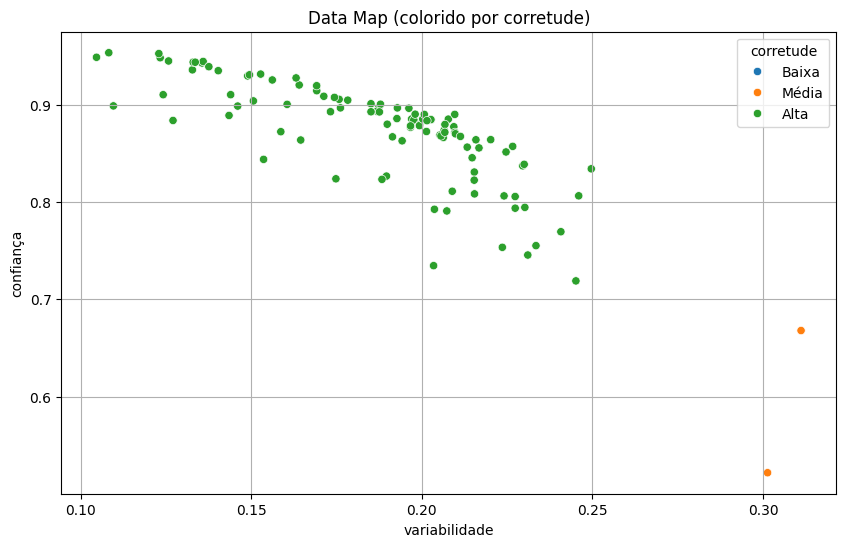

In [69]:
plt.figure(figsize=(10, 6))
# Plotar Data Map colorido por corretude
sns.scatterplot(data=df_map, x='variabilidade', y='confiança', hue=pd.cut(df_map['corretude'], bins=[0, 0.3, 0.7, 1], labels=['Baixa', 'Média', 'Alta']))
plt.title("Data Map (colorido por corretude)")
plt.grid(True)
plt.show()

#### 3.4 Plotar DataMap por classe

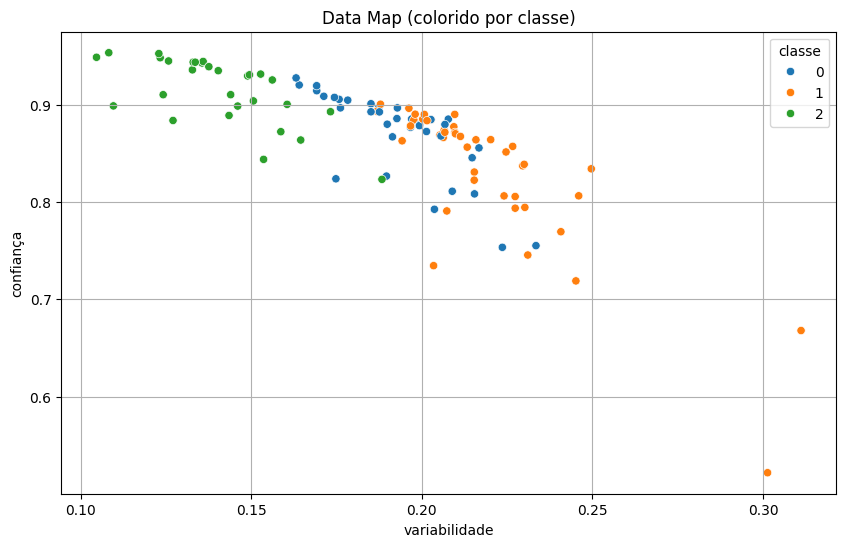

In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_map, x='variabilidade', y='confiança', hue='classe', palette='tab10')
plt.title("Data Map (colorido por classe)")
plt.grid(True)
plt.show()

#### 3.5 Procurando inconsistências

In [71]:
# Exemplo com thresholds ajustados
suspeitos = df_map[
    (df_map['confiança'] < 0.6) &
    (df_map['variabilidade'] > 0.27)
]
print(suspeitos)



     confiança  variabilidade  corretude  classe
100   0.521628        0.30134        0.5       1


## 4. Conjuntos desbalanceados

### 4.1 Classificação (2 pts)

#### 4.1.1 Imports

In [72]:
import numpy as np
import pickle
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

#### 4.1.2 Carregando e Convertendo dados

In [73]:
filename = "A652.pickle"
with open(filename, 'rb') as f:
    X_train, y_train, X_val, y_val, X_test, y_test = pickle.load(f)    

# === 2. Convertendo para classificação binária ===
# Se y == 0 -> 0; senão -> 1
y_train_bin = (y_train > 0).astype(int)
y_val_bin   = (y_val > 0).astype(int)
y_test_bin  = (y_test > 0).astype(int)


In [74]:
print("y_train_1:", y_train_bin.sum())  # Conta quantos exemplos são da classe 1
print("y_train_0", y_train_bin.shape) # Conta quantos exemplos são da classe 0
print("y_val_1:", y_val_bin.sum())  
print("y_val shape:", y_val_bin.shape)
print("y_test_1:", y_test_bin.sum())  
print("y_test shape:", y_test_bin.shape)


y_train_1: 754
y_train_0 (10012, 1)
y_val_1: 229
y_val shape: (2506, 1)
y_test_1: 813
y_test shape: (9582, 1)


#### 4.1.3 Função auxiliar para treinar e avaliar

In [75]:

def avaliar_modelo(modelo, X_train, y_train, X_test, y_test, titulo): # Função auxiliar para treinar e avaliar
    modelo.fit(X_train, y_train) # treina o modelo
    y_pred = modelo.predict(X_test) # faz previsões no conjunto de teste
    print(f"\n=== {titulo} ===") # imprime o título da avaliação
    print("Matriz de Confusão:")
    print(confusion_matrix(y_test, y_pred))
    print("Relatório de Classificação:")
    print(classification_report(y_test, y_pred, zero_division=0))

#### 4.1.4 Modelo sem balanceamento

In [76]:
modelo_base = GradientBoostingClassifier()
avaliar_modelo(modelo_base, X_train, y_train_bin, X_test, y_test_bin, "Modelo sem balanceamento")

c:\Anaconda\envs\IA_25.1\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



=== Modelo sem balanceamento ===
Matriz de Confusão:
[[8666  103]
 [ 510  303]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      8769
           1       0.75      0.37      0.50       813

    accuracy                           0.94      9582
   macro avg       0.85      0.68      0.73      9582
weighted avg       0.93      0.94      0.93      9582



#### 4.1.5 Undersampling 

In [77]:
undersampler = RandomUnderSampler(random_state=42) # Undersampling para balancear as classes 
X_under, y_under = undersampler.fit_resample(X_train, y_train_bin) # aplica o undersampling que reduz a classe majoritária
modelo_under = GradientBoostingClassifier()
avaliar_modelo(modelo_under, X_under, y_under, X_test, y_test_bin, "Modelo com Undersampling")


=== Modelo com Undersampling ===
Matriz de Confusão:
[[7939  830]
 [ 234  579]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      8769
           1       0.41      0.71      0.52       813

    accuracy                           0.89      9582
   macro avg       0.69      0.81      0.73      9582
weighted avg       0.92      0.89      0.90      9582



#### 4.1.6 Oversampling

In [78]:
oversampler = RandomOverSampler(random_state=42) # Oversampling para balancear as classes
X_over, y_over = oversampler.fit_resample(X_train, y_train_bin) # aplica o oversampling que aumenta a classe minoritária
modelo_over = GradientBoostingClassifier()
avaliar_modelo(modelo_over, X_over, y_over, X_test, y_test_bin, "Modelo com Oversampling")


=== Modelo com Oversampling ===
Matriz de Confusão:
[[8234  535]
 [ 274  539]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      8769
           1       0.50      0.66      0.57       813

    accuracy                           0.92      9582
   macro avg       0.73      0.80      0.76      9582
weighted avg       0.93      0.92      0.92      9582



#### 4.1.7 Alteração de limiar

In [79]:
modelo_limiar = GradientBoostingClassifier()
modelo_limiar.fit(X_train, y_train_bin)
probas = modelo_limiar.predict_proba(X_test)[:, 1]
y_pred_limiar = (probas >= 0.3).astype(int)  # limiar ajustado (ex: 0.3)
print("\n=== Modelo com Alteração de Limiar (0.3) ===")
print("Matriz de Confusão:")
print(confusion_matrix(y_test_bin, y_pred_limiar))
print("Relatório de Classificação:")
print(classification_report(y_test_bin, y_pred_limiar, zero_division=0))

c:\Anaconda\envs\IA_25.1\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



=== Modelo com Alteração de Limiar (0.3) ===
Matriz de Confusão:
[[8563  206]
 [ 391  422]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      8769
           1       0.67      0.52      0.59       813

    accuracy                           0.94      9582
   macro avg       0.81      0.75      0.78      9582
weighted avg       0.93      0.94      0.93      9582



### 4.2 Regressão (2 pts)

#### 4.2.1 Carregando e Convertendo


In [80]:
import numpy as np
import pickle
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt

filename = "A652.pickle"
with open(filename, 'rb') as f:
    X_train, y_train, X_val, y_val, X_test, y_test = pickle.load(f)


# === 2. Criar versão binária para detectar se há chuva (0 ou 1) ===
y_train_bin = (y_train > 0).astype(int)
y_val_bin = (y_val > 0).astype(int)
y_test_bin = (y_test > 0).astype(int)

#### 4.2.2 Treinar classificador C para prever se vai chover 

In [81]:
C = GradientBoostingClassifier()
C.fit(X_train, y_train_bin)

c:\Anaconda\envs\IA_25.1\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingClassifier()

#### 4.2.3 Selecionar apenas os exemplos com chuva previstos por C

In [82]:
mask_train_pos = C.predict(X_train) == 1
X_train_1 = X_train[mask_train_pos]
y_train_1 = y_train[mask_train_pos]


#### 4.2.4 Treinar regressor R para prever quanto vai chover

In [83]:
R = GradientBoostingRegressor()
R.fit(X_train_1, y_train_1)

c:\Anaconda\envs\IA_25.1\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingRegressor()

#### 4.2.5 Prever no conjunto de teste usando o modelo combinado C + R

In [ ]:
y_pred_final = []
for x in X_test:
    if C.predict([x])[0] == 0:
        y_pred_final.append(0)
    else:
        y_pred_final.append(R.predict([x])[0])
y_pred_final = np.array(y_pred_final)

#### 4.2.6 Calcular RMSE global

In [85]:
rmse_total = sqrt(mean_squared_error(y_test, y_pred_final))
print(f"RMSE total (modelo combinado): {rmse_total:.4f}")

RMSE total (modelo combinado): 1.3657
